In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker
from scipy.signal import find_peaks, savgol_filter

# Aluminum

In [15]:
df1=pd.read_csv('channel_1.txt', sep='\t'); df2= pd.read_csv('channel_2.txt', sep='\t')
print(df1.head(3)); print(df2.head(3))

   Wavelength [nm]  Intensity
0         180.2263  50.359985
1         180.5152  46.461907
2         180.8041  36.155257
   Wavelength [nm]  intensity
0         165.3892 -14.520020
1         165.6764 -17.002648
2         165.9636 -18.884967


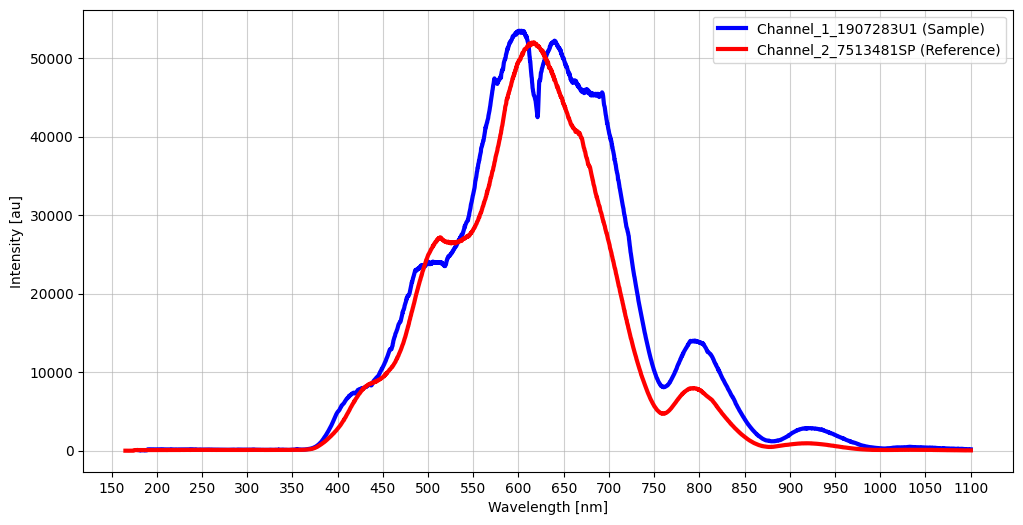

In [16]:
#Raw plotting
plt.figure( figsize=(12, 6))   #plt.figure(figsize=(12, 6), dpi=150, facecolor='#f0f0f0', edgecolor='black', linewidth=1,layout='tight')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))
plt.plot(df1.iloc[:,0], df1.iloc[:,1], 'b', lw=3,  label='Channel_1_1907283U1 (Sample)')
plt.plot(df2.iloc[:,0], df2.iloc[:,1], 'r', lw=3,  label='Channel_2_7513481SP (Reference)')
#plt.xlim(620, 630) #plt.ylim(40000, 500000)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.grid(True, alpha=.6)
plt.legend()
#plt.title()
plt.savefig('Alu1')
plt.show()

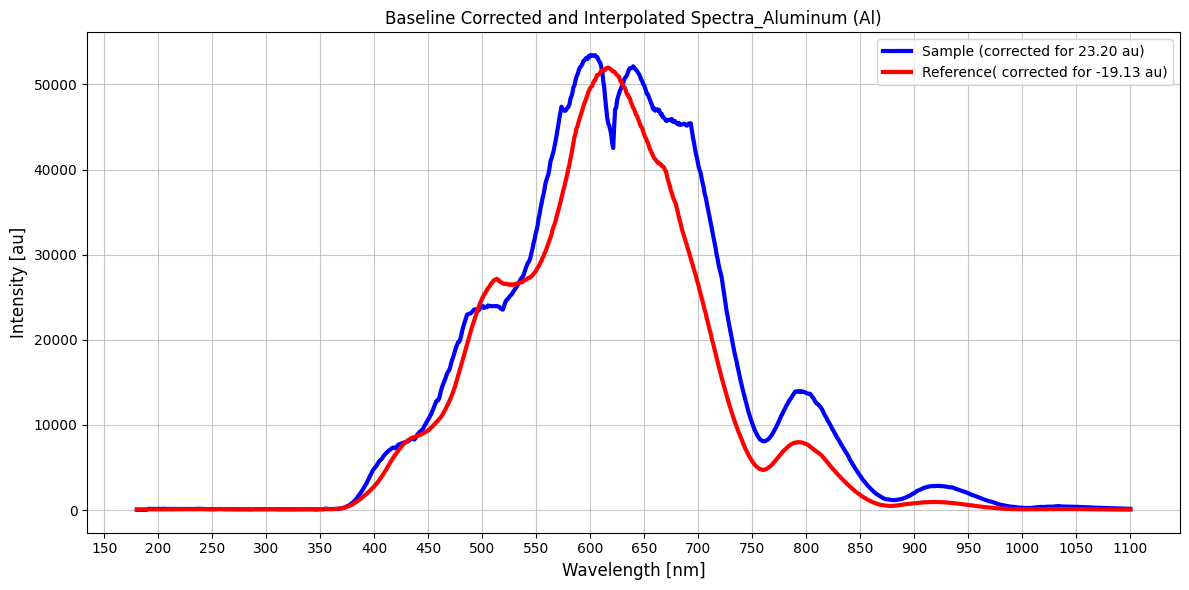

In [17]:
# 1. Baseline Correction (Subtracting the minimum)  #zero shifting
df1.iloc[:, 1] -= df1.iloc[:, 1].min()
df2.iloc[:, 1] -= df2.iloc[:, 1].min()

# 2. Interpolation onto a common wavelength range
x_min = max(df1.iloc[0, 0], df2.iloc[0, 0])
x_max = min(df1.iloc[-1, 0], df2.iloc[-1, 0])
common_x = np.linspace(x_min, x_max, 1000)

df1_interp = np.interp(common_x, df1.iloc[:, 0], df1.iloc[:, 1])
df2_interp = np.interp(common_x, df2.iloc[:, 0], df2.iloc[:, 1])

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.plot(common_x, df1_interp, 'b', lw=3, label='Sample (corrected for 23.20 au)')
plt.plot(common_x, df2_interp, 'r', lw=3, label='Reference( corrected for -19.13 au)')

# Axis formatting: Set 50 nm steps
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))

#plt.title('Corrected and Interpolated Spectra', fontsize=12)
plt.xlabel('Wavelength [nm]', fontsize=12)
plt.ylabel('Intensity [au]', fontsize=12)
plt.grid(True, alpha=0.7)
plt.legend()
#plt.xlim(620, 900)
plt.title('Baseline Corrected and Interpolated Spectra_Aluminum (Al)')
plt.tight_layout()
plt.savefig('AL23')
plt.show()

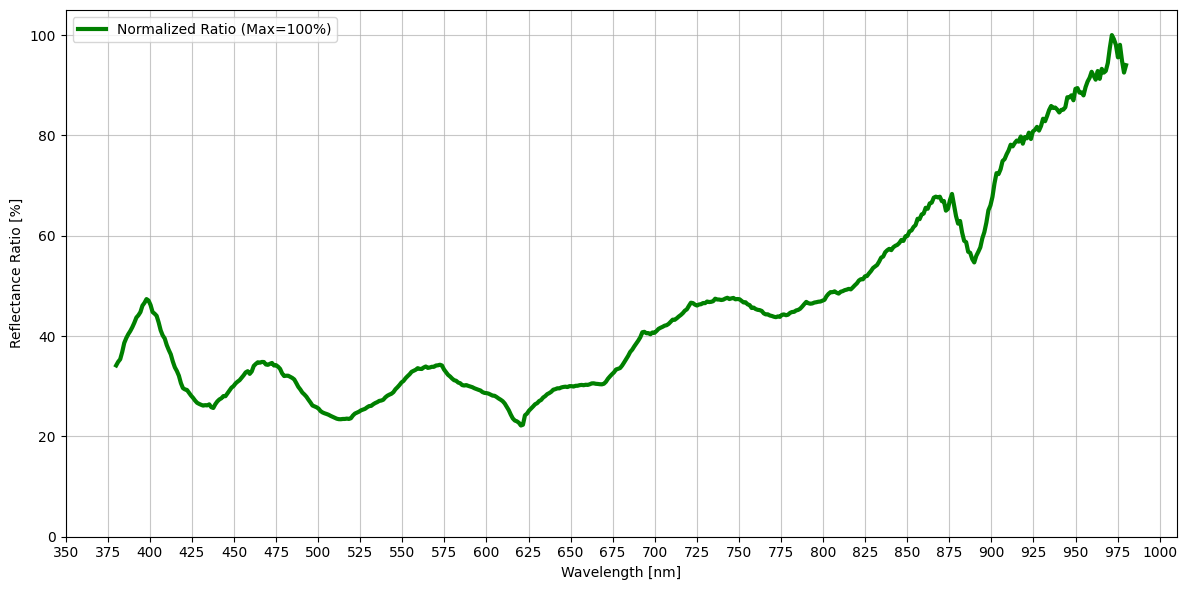

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
           380.0     1.2852            0.3414                 34.14
           405.0     1.6189            0.4301                 43.01
           430.0     0.9933            0.2639                 26.39
           455.0     1.2001            0.3188                 31.88
           480.0     1.2050            0.3201                 32.01
           505.0     0.9209            0.2447                 24.47
           530.0     0.9803            0.2604                 26.04
           555.0     1.2303            0.3269                 32.69
           580.0     1.1788            0.3132                 31.32
           605.0     1.0548            0.2802                 28.02
           630.0     1.0011            0.2660                 26.60
           655.0     1.1340            0.3013                 30.13
           680.0     1.2728            0.3381                 33.81
           705.0     1.5760            0.4187   

In [27]:
df = pd.read_csv('11.csv', sep=';', decimal=',', skiprows=1)
df1 = df.iloc[:, [0, 1]].dropna() # Sample (Wavelength, Intensity)
df2 = df.iloc[:, [2, 3]].dropna() # Reference (Wavelength, Intensity)

# --- NEW BASELINE CORRECTION (Zero Shifting) ---
df1.iloc[:, 1] -= df1.iloc[:, 1].min()
df2.iloc[:, 1] -= df2.iloc[:, 1].min()

# 2. Interpolation onto common_x for Plotting
common_x = np.linspace(380, 980, 500)
y1_s = np.interp(common_x, df1.iloc[:, 0], df1.iloc[:, 1])
y2_s = np.interp(common_x, df2.iloc[:, 0], df2.iloc[:, 1])

# Calculate ratio (Sample / Reference) and scale to 100% MAX
# Added a small epsilon to avoid division by zero
ratio_s = y1_s / y2_s
norm_plota = (ratio_s / ratio_s.max()) * 100

# 3. Table generation (30 nm steps)
steps_x =  np.linspace(380, 980, 25) # Rounds to neat steps
y1_t = np.interp(steps_x, df1.iloc[:, 0], df1.iloc[:, 1])
y2_t = np.interp(steps_x, df2.iloc[:, 0], df2.iloc[:, 1])

# Calculate Table Ratios scaled to the plot maximum
raw_r_t = y1_t / y2_t
norm_r_t = raw_r_t / ratio_s.max() 
norm_pct_t = norm_r_t * 100

# 4. Create Results Table
df_step = pd.DataFrame({
    'Wavelength [nm]': steps_x,
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})

# 5. Plotting
plt.figure(figsize=(12, 6))
plt.plot(common_x, norm_plota, lw=3, color='green', label='Normalized Ratio (Max=100%)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(25))
plt.ylim(0, 105) 
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
#plt.title('Normalized Intensity Ratio (Baseline Corrected & Common Range)')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.savefig('ALR23.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
             380     1.2852            0.7314                 73.14
             405     1.6189            0.9212                 92.12
             430     0.9933            0.5652                 56.52
             455     1.2001            0.6829                 68.29
             480     1.2050            0.6857                 68.57
             505     0.9209            0.5240                 52.40
             530     0.9803            0.5578                 55.78
             555     1.2303            0.7001                 70.01
             580     1.1788            0.6708                 67.08
             605     1.0548            0.6002                 60.02
             630     1.0011            0.5697                 56.97
             655     1.1340            0.6453                 64.53
             680     1.2728            0.7243                 72.43
             705     1.5760            0.8968   

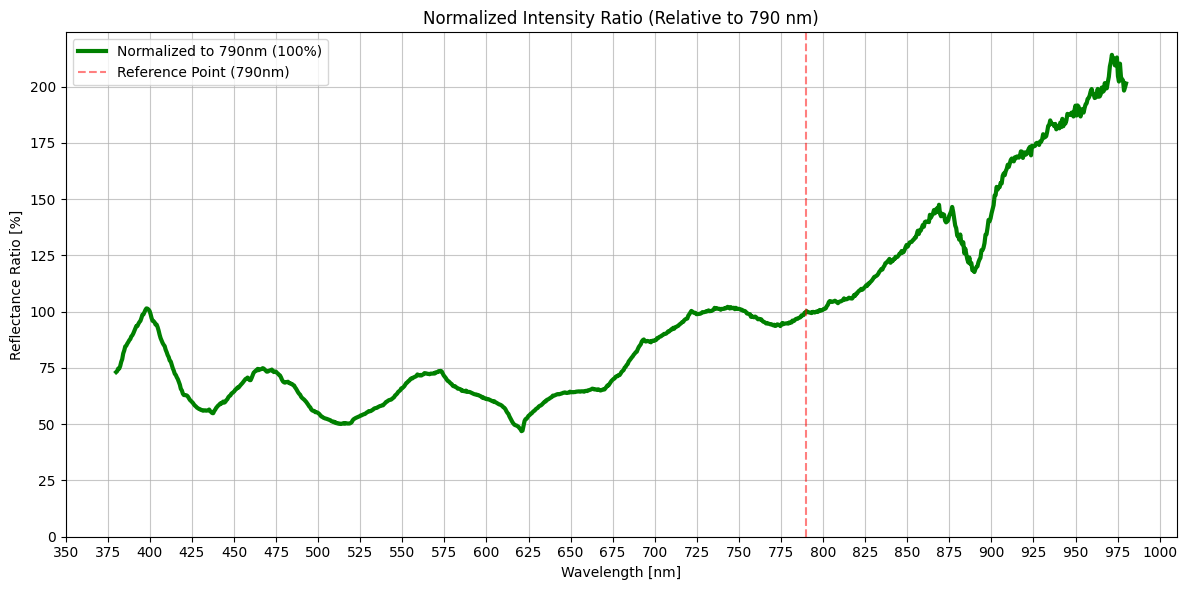

In [19]:
# 1. Load Data
df = pd.read_csv('11.csv', sep=';', decimal=',', skiprows=1)
df1, df2 = df.iloc[:, [0, 1]].dropna(), df.iloc[:, [2, 3]].dropna()

# --- BASELINE CORRECTION ---
df1.iloc[:, 1] -= df1.iloc[:, 1].min()
df2.iloc[:, 1] -= df2.iloc[:, 1].min()

# 2. Interpolation
common_x = np.linspace(380, 980, 1000)
y1_s = np.interp(common_x, df1.iloc[:, 0], df1.iloc[:, 1])
y2_s = np.interp(common_x, df2.iloc[:, 0], df2.iloc[:, 1])

ratio_s = y1_s/y2_s
# --- NORMALIZATION (Relative to 790 nm) ---
ratio_at_790 = np.interp(790, common_x, ratio_s)
norm_plot = (ratio_s / ratio_at_790) * 100

# 3. Table generation (30 nm steps)
steps_x = np.arange(380, 990, 25)
y1_t, y2_t = np.interp(steps_x, df1.iloc[:, 0], df1.iloc[:, 1]), np.interp(steps_x, df2.iloc[:, 0], df2.iloc[:, 1])
#raw_r_t = np.divide(y1_t, y2_t, out=np.zeros_like(y1_t), where=y2_t != 0)
raw_r_t = y1_t/y2_t
norm_r_t = raw_r_t / ratio_at_790 
norm_pct_t = norm_r_t * 100

# 4. Results Table
df_step = pd.DataFrame({
    'Wavelength [nm]': steps_x,
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})

# 5. Plotting
plt.figure(figsize=(12, 6))
plt.plot(common_x, norm_plot, lw=3, color='green', label='Normalized to 790nm (100%)')
plt.axvline(x=790, color='red', linestyle='--', alpha=0.5, label='Reference Point (790nm)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(25))
plt.ylim(0, norm_plot.max() + 10)
#plt.ylim(0, 105)
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance Ratio [%]')
plt.title('Normalized Intensity Ratio (Relative to 790 nm)'); plt.grid(True, alpha=.7); plt.legend()
plt.tight_layout()
plt.savefig('ALR231.png')
print(df_step.to_string(index=False))

# Gold (Au)

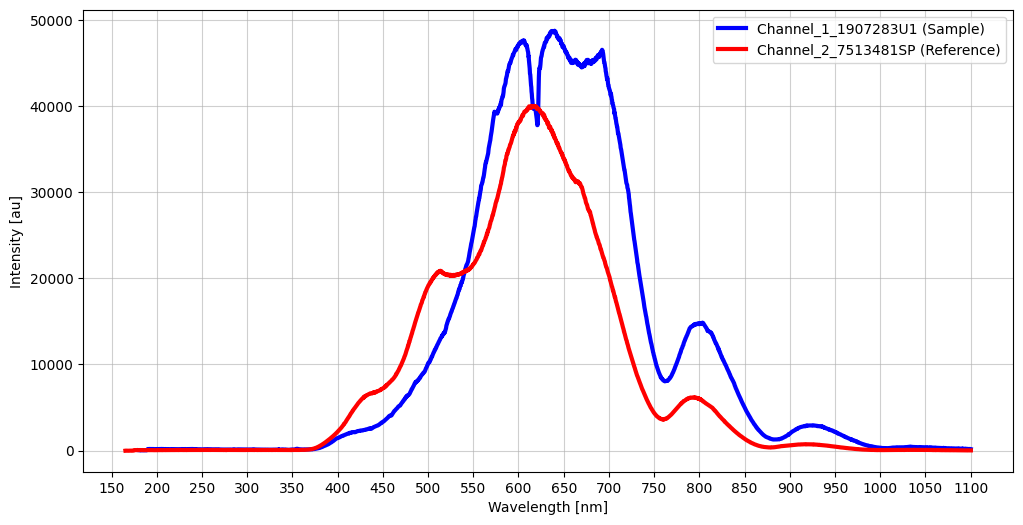

In [20]:
# Load data with semicolon separator and decimal comma, skipping the first row of metadata
df = pd.read_csv('111.csv', sep=';', skiprows=1, decimal=',')
# Plot both channels from the same DataFrame
plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
# Channel 1 and 2, Wavelength (column 0) vs Intensity (column 1)
plt.plot(df.iloc[:,0], df.iloc[:,1], lw=3, color='blue', label='Channel_1_1907283U1 (Sample)')
plt.plot(df.iloc[:,2], df.iloc[:,3], lw=3, color='red', label='Channel_2_7513481SP (Reference)')
#plt.title('hhh')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.grid(True, alpha=.6)
plt.legend()
plt.show()

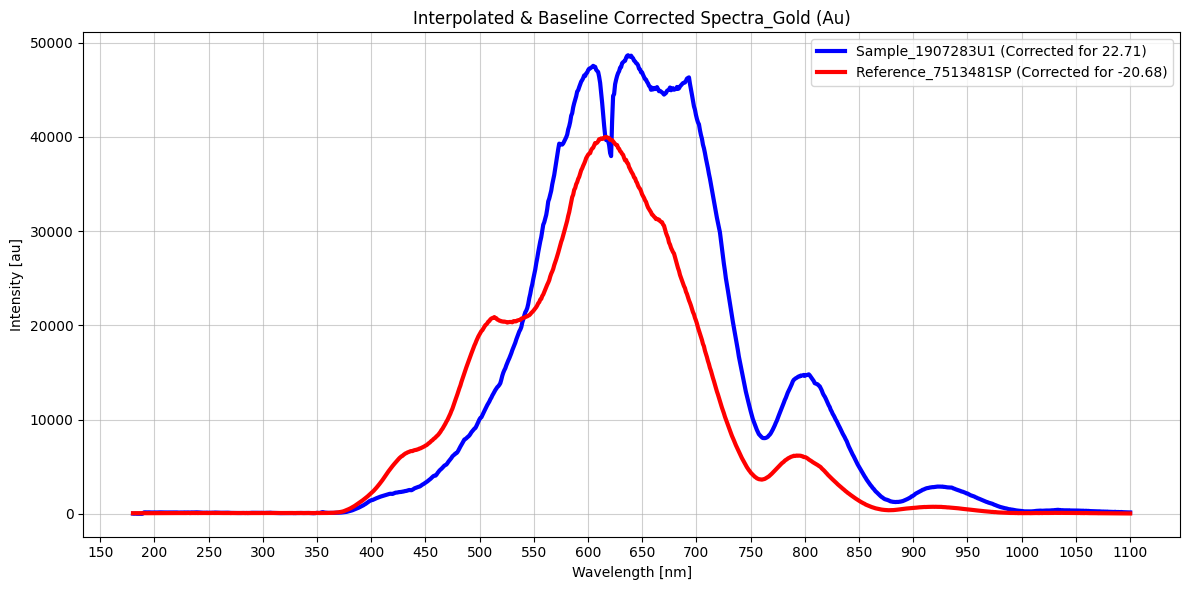

In [21]:
df3, df4 = df.iloc[:, [0, 1]].dropna(), df.iloc[:, [2, 3]].dropna()
# Baseline correction
df3.iloc[:, 1] -= df3.iloc[:, 1].min()
df4.iloc[:, 1] -= df4.iloc[:, 1].min()

# Create a common wavelength range for interpolation
common_x = np.linspace(max(df3.iloc[0,0], df4.iloc[0,0]), min(df3.iloc[-1,0], df4.iloc[-1,0]), 1000)

# Interpolate both channels onto the common range
df1_interp = np.interp(common_x, df3.iloc[:,0], df3.iloc[:,1])
df2_interp = np.interp(common_x, df4.iloc[:,0], df4.iloc[:,1])

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(common_x, df1_interp, color='blue', lw=3, label='Sample_1907283U1 (Corrected for 22.71)')
ax.plot(common_x, df2_interp, color='red', lw=3, label='Reference_7513481SP (Corrected for -20.68)')

# Set x-axis ticks every 50 nm
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Intensity [au]')
ax.set_title('Interpolated & Baseline Corrected Spectra_Gold (Au)')
ax.grid(True, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('Au23.png')


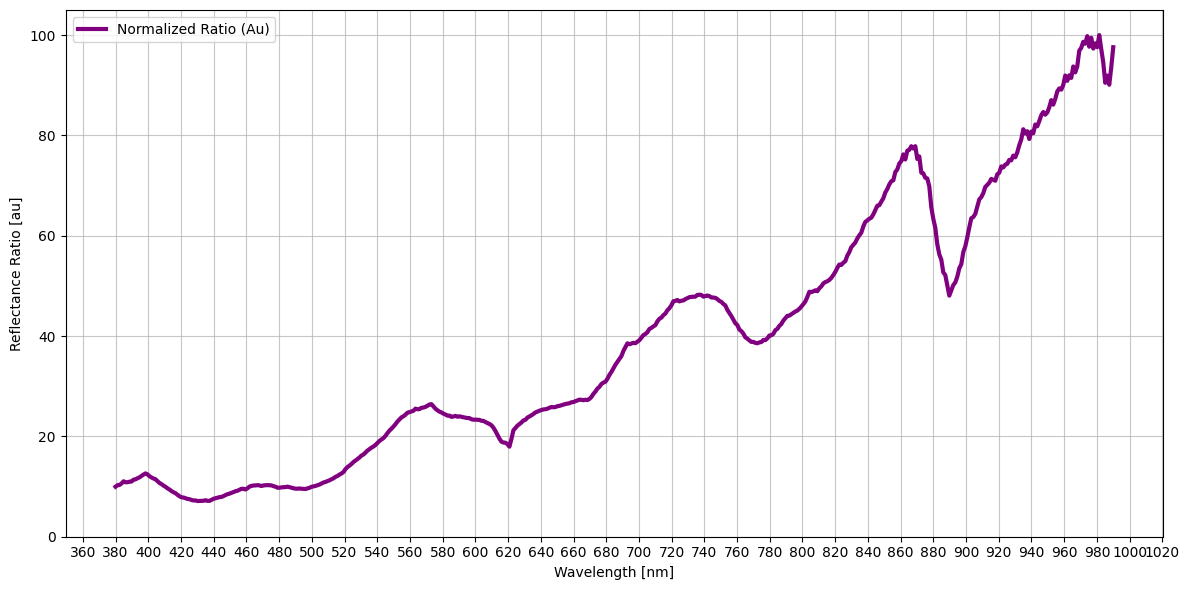

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
          380.00     0.5279            0.0997                  9.97
          405.42     0.5903            0.1115                 11.15
          430.83     0.3804            0.0719                  7.19
          456.25     0.4977            0.0940                  9.40
          481.67     0.5231            0.0988                  9.88
          507.08     0.5710            0.1078                 10.78
          532.50     0.8813            0.1665                 16.65
          557.92     1.3008            0.2457                 24.57
          583.33     1.2785            0.2415                 24.15
          608.75     1.1895            0.2247                 22.47
          634.17     1.2818            0.2421                 24.21
          659.58     1.4157            0.2674                 26.74
          685.00     1.7919            0.3384                 33.84
          710.42     2.2575            0.4264   

In [22]:
# 1. Load Data
df = pd.read_csv('111.csv', sep=';', decimal=',', skiprows=1)
df3 = df.iloc[:, [0, 1]].dropna() # Sample (Wavelength, Intensity)
df4 = df.iloc[:, [2, 3]].dropna() # Reference (Wavelength, Intensity)
# --- NEW BASELINE CORRECTION (Zero Shifting) ---
df3.iloc[:, 1] -= df3.iloc[:, 1].min()
df4.iloc[:, 1] -= df4.iloc[:, 1].min()
# 2. Interpolation onto common_x for Plotting
common_x = np.linspace(380, 990, 500)
y1_s = np.interp(common_x, df3.iloc[:, 0], df3.iloc[:, 1])
y2_s = np.interp(common_x, df4.iloc[:, 0], df4.iloc[:, 1])

# Calculate ratio (Sample / Reference) and scale to 100% MAX
# Note: Using np.divide is safer if y2_s contains zeros from baseline correction
ratio_s = y1_s/y2_s
norm_plotg = (ratio_s / ratio_s.max()) * 100

# 3. Table generation (30 points)
steps_x = np.linspace(380, 990, 25) 
y1_t = np.interp(steps_x, df3.iloc[:, 0], df3.iloc[:, 1])
y2_t = np.interp(steps_x, df4.iloc[:, 0], df4.iloc[:, 1])

# Calculate Table Ratios scaled to the plot maximum
raw_r_t = y1_t/ y2_t
norm_r_t = raw_r_t / ratio_s.max() 
norm_pct_t = norm_r_t * 100

# 4. Create Results Table
df_step = pd.DataFrame({
    # Rounding Wavelength to 2 decimal places
    'Wavelength [nm]': np.round(steps_x, 2), 
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})
# 5. Plotting
plt.figure(figsize=(12, 6))
plt.plot(common_x, norm_plotg, lw=3, color='purple', label='Normalized Ratio (Au)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 105) 
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [au]')
#plt.title('Normalized Intensity Ratio (Baseline Corrected & Common Range)')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.savefig('Au23R.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

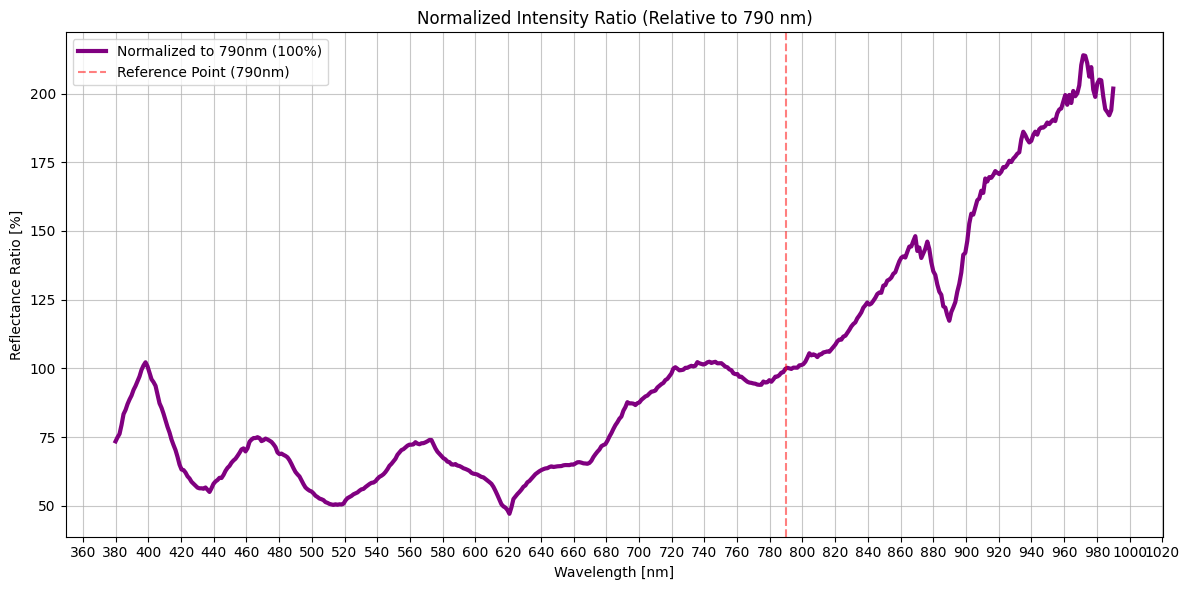

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
             380     1.2852            0.7345                 73.45
             405     1.6189            0.9252                 92.52
             430     0.9933            0.5677                 56.77
             455     1.2001            0.6859                 68.59
             480     1.2050            0.6887                 68.87
             505     0.9209            0.5263                 52.63
             530     0.9803            0.5602                 56.02
             555     1.2303            0.7031                 70.31
             580     1.1788            0.6737                 67.37
             605     1.0548            0.6028                 60.28
             630     1.0011            0.5722                 57.22
             655     1.1340            0.6481                 64.81
             680     1.2728            0.7274                 72.74
             705     1.5760            0.9007   

In [23]:
# 1. Load Data
df = pd.read_csv('11.csv', sep=';', decimal=',', skiprows=1)
df3 = df.iloc[:, [0, 1]].dropna() # Sample (Wavelength, Intensity)
df4 = df.iloc[:, [2, 3]].dropna() # Reference (Wavelength, Intensity)

# --- BASELINE CORRECTION (Zero Shifting) ---
# Subtract min to set baseline to 0
df3.iloc[:, 1] -= df3.iloc[:, 1].min()
df4.iloc[:, 1] -= df4.iloc[:, 1].min()

# 2. Interpolation
common_x = np.linspace(380, 990, 500)
y1_s = np.interp(common_x, df3.iloc[:, 0], df3.iloc[:, 1])
y2_s = np.interp(common_x, df4.iloc[:, 0], df4.iloc[:, 1])

# Calculate raw ratio safely using np.divide to handle baseline zeros
ratio_s  = y1_s/ y2_s

# --- NORMALIZATION (Relative to 790 nm) ---
# Find the exact raw ratio at 790 nm for scaling
ratio_at_790 = np.interp(790, common_x, ratio_s)
# Scale so that 790nm = 100%
norm_plot = (ratio_s / ratio_at_790) * 100

# 3. Table generation (30 nm steps)
# Using 991 ensures the 990nm point is included in the table
steps_x = np.arange(380, 990, 25)
y1_t = np.interp(steps_x, df3.iloc[:, 0], df3.iloc[:, 1])
y2_t = np.interp(steps_x, df4.iloc[:, 0], df4.iloc[:, 1])

# Calculate Table Ratios scaled to the 790nm reference
raw_r_t = y1_t/ y2_t
norm_r_t = raw_r_t / ratio_at_790 
norm_pct_t = norm_r_t * 100

# 4. Create Results Table
df_step = pd.DataFrame({
    'Wavelength [nm]': steps_x,
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})

# 5. Plotting
plt.figure(figsize=(12, 6))
plt.plot(common_x, norm_plot, lw=3, color='purple', label='Normalized to 790nm (100%)')
plt.axvline(x=790, color='red', linestyle='--', alpha=0.5, label='Reference Point (790nm)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
#plt.ylim(0, norm_plot.max() + 10) 
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Normalized Intensity Ratio (Relative to 790 nm)')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.savefig('AuR231.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

# Ratio

# 1. Baseline Correction
df1.iloc[:, 1] -= df1.iloc[:, 1].min()
df2.iloc[:, 1] -= df2.iloc[:, 1].min()

# 2. Smooth Interpolation for the Plot (380-990nm, 1000 points)
range_x = np.linspace(390, 1000, 600)
y1_smooth = np.interp(range_x, df1.iloc[:, 0], df1.iloc[:, 1])
y2_smooth = np.interp(range_x, df2.iloc[:, 0], df2.iloc[:, 1])

# Calculate smooth ratios for plotting
ratio_smooth = y1_smooth / y2_smooth
norm_ratio_pct_smooth = (ratio_smooth / ratio_smooth[400]) * 100

# 3. 30 nm steps for the Table (380-990nm, 21 points)
steps_x = np.arange(390, 990, 30)
y1_step = np.interp(steps_x, df1.iloc[:, 0], df1.iloc[:, 1])
y2_step = np.interp(steps_x, df2.iloc[:, 0], df2.iloc[:, 1])

# Calculate table ratios
raw_ratio_step = y1_step / y2_step
norm_ratio_step = raw_ratio_step / raw_ratio_step.max()
norm_ratio_pct_step = norm_ratio_step * 100

# Create the requested table
df_step = pd.DataFrame({
    'Wavelength [nm]': steps_x,
    'Raw Ratio': raw_ratio_step,
    'Normalized Ratio': norm_ratio_step,
    'Normalized Ratio [%]': norm_ratio_pct_step
})

# 4. Plotting (Original Style)
plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.ylim(0, 100) 
plt.plot(range_x, norm_ratio_pct_smoothAu, lw=3, color='green', label='Normalized Ratio [%] Aluminum')
plt.plot(range_x, norm_ratio_pct_smoothAl, lw=3, color='purple', label='Normalized Ratio [%] Gold')
#plt.plot(range_x, norm_ratio_pct_smoothAu / norm_ratio_pct_smoothAl, lw=3, color='red', label='Normalized Ratio [%]')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Normalized Intensity Ratio (Channel 1 / Channel 2)')
plt.grid(True, alpha=.6)
#plt.ylim(0, 1.1)
plt.legend()
plt.savefig('R1_AlAu_2302')
plt.show()
# Display the table
print(df_step.to_string(index=False))

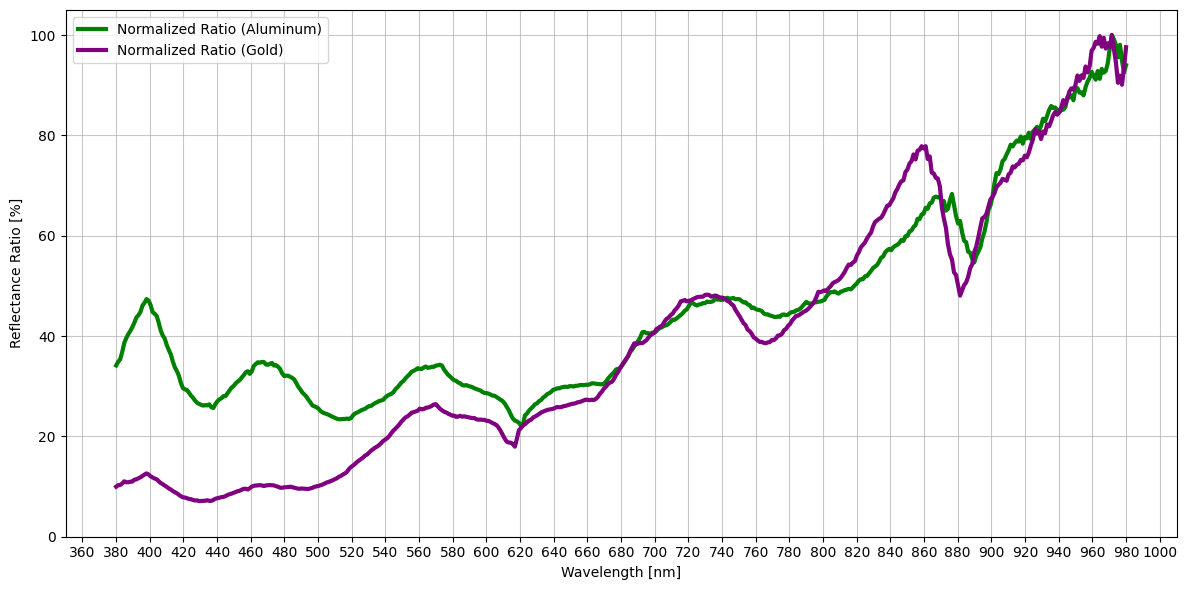

In [28]:
range_x = np.linspace(380, 980, 500) # Changed from 600 to 500 to match data shape
# 5. Plotting
plt.figure(figsize=(12, 6))
plt.plot(range_x, norm_plota, lw=3, color='green', label='Normalized Ratio (Aluminum)')
plt.plot(range_x, norm_plotg, lw=3, color='purple', label='Normalized Ratio (Gold)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 105) 
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.savefig('ALAuR.png')
plt.show()

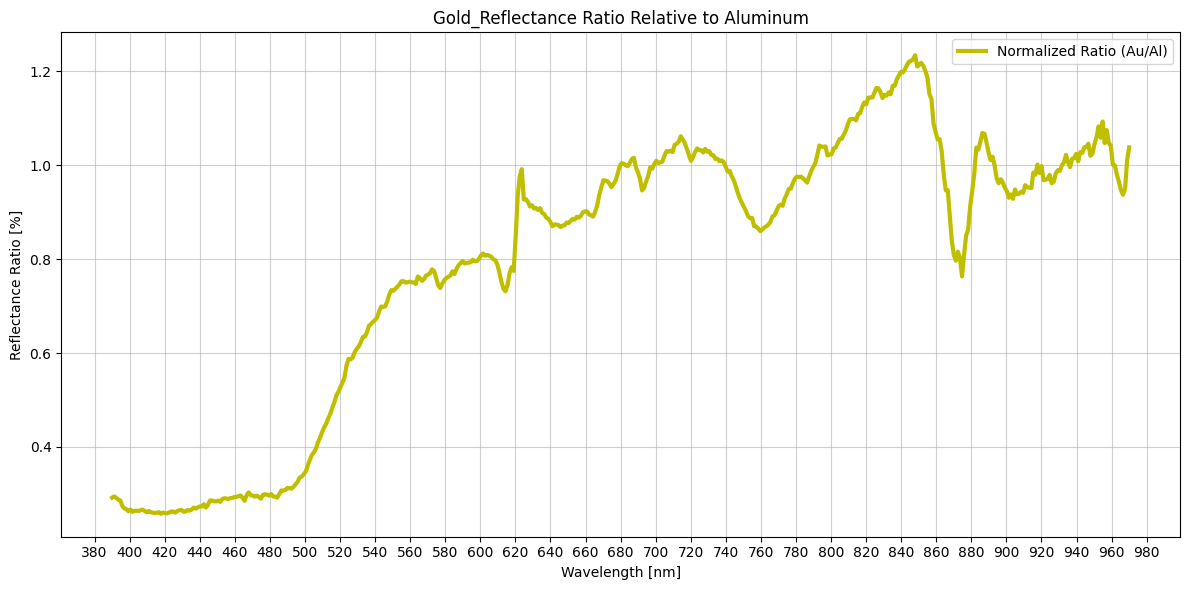

In [25]:
#range_x = (df3.iloc[:, 0])
#raw_ratio_step =  df6.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric)
range_x = np.linspace(390, 970, 500)
f1= norm_plotg/norm_plota
plt.figure(figsize=(12, 6))
plt.plot(range_x, f1, lw=3, color='y', label='Normalized Ratio (Au/Al)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
#plt.xlim(380, 850)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Gold_Reflectance Ratio Relative to Aluminum')
plt.grid(True, alpha=.6)
plt.legend()
plt.savefig('Au_Al.png')
plt.tight_layout()
plt.show()


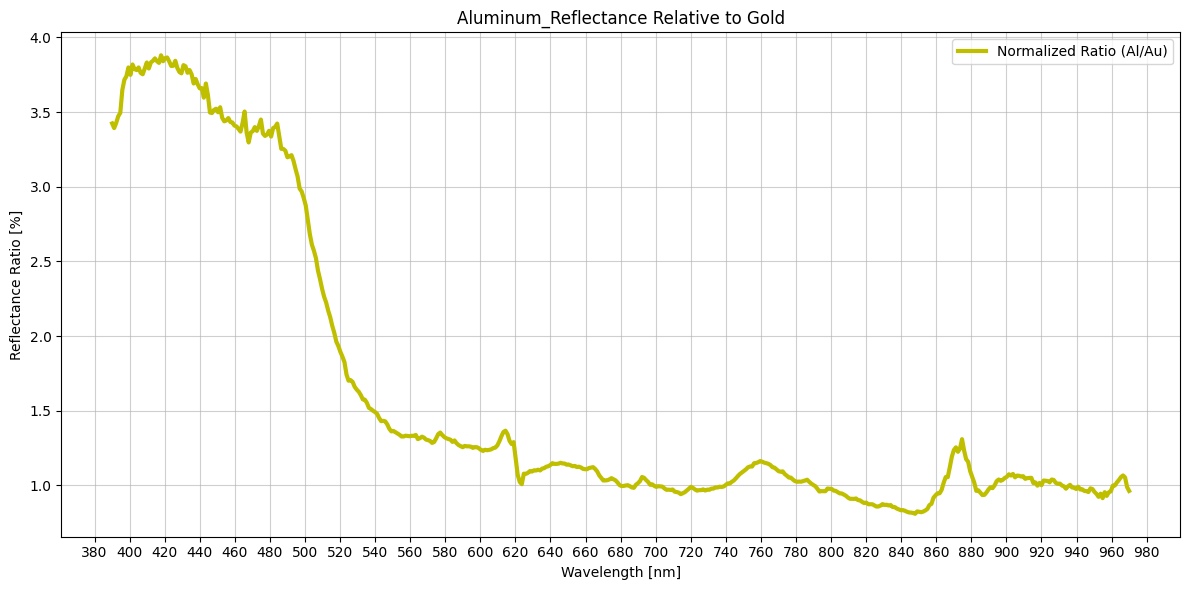

In [26]:
#range_x = (df3.iloc[:, 0])
#raw_ratio_step =  df6.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric)
range_x = np.linspace(390, 970, 500)
f2=norm_plota/norm_plotg
plt.figure(figsize=(12, 6))
plt.plot(range_x, f2, lw=3, color='y', label='Normalized Ratio (Al/Au)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
#plt.xlim(380, 850)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Aluminum_Reflectance Relative to Gold')
plt.grid(True, alpha=.6)
plt.legend()
plt.savefig('Al_Au.png')
plt.tight_layout()
plt.show()
